In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel("part_1_ecommerce_customer_segmentation.xlxs.csv.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4395 non-null   object        
 1   StockCode    4395 non-null   object        
 2   Description  4328 non-null   object        
 3   Category     4395 non-null   object        
 4   Quantity     4395 non-null   int64         
 5   InvoiceDate  4395 non-null   datetime64[ns]
 6   UnitPrice    4395 non-null   float64       
 7   CustomerID   4187 non-null   object        
 8   Country      4395 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 309.2+ KB


In [5]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,67
Category,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,208
Country,0


In [6]:
df.duplicated().sum()

np.int64(35)

In [7]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,4395,4395,4328,4395,4395.000000,4395,4395.000000,4187,4395
unique,1450,30,30,11,NaN,NaN,NaN,692,11
top,INV500643,P1006,Smart Watch Strap,Home,NaN,NaN,NaN,C10725,United Kingdom
freq,9,170,169,846,NaN,NaN,NaN,25,2427
mean,NaN,NaN,NaN,NaN,2.826394,2025-06-13 22:25:17.597269504,747.081477,NaN,NaN
min,NaN,NaN,NaN,NaN,-50.000000,2025-01-02 14:47:00,-2244.520000,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000,2025-03-20 14:25:00,328.200000,NaN,NaN
50%,NaN,NaN,NaN,NaN,2.000000,2025-06-14 15:03:00,544.320000,NaN,NaN
75%,NaN,NaN,NaN,NaN,4.000000,2025-09-04 22:52:00,950.470000,NaN,NaN
max,NaN,NaN,NaN,NaN,50.000000,2025-11-27 19:27:00,2939.580000,NaN,NaN


In [8]:
df = df.drop_duplicates()

In [9]:
df = df[df["CustomerID"].notna()]

In [10]:
df = df[df["Description"].notna()]

In [11]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [12]:
df = df[df["Quantity"] > 0]

In [13]:
df = df[df["UnitPrice"] > 0]

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

In [41]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3848 entries, 0 to 4359
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    3848 non-null   object        
 1   StockCode    3848 non-null   object        
 2   Description  3848 non-null   object        
 3   Category     3848 non-null   object        
 4   Quantity     3848 non-null   int64         
 5   InvoiceDate  3848 non-null   datetime64[ns]
 6   UnitPrice    3848 non-null   float64       
 7   CustomerID   3848 non-null   object        
 8   Country      3848 non-null   object        
 9   Revenue      3848 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 330.7+ KB


In [17]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Category,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0


In [18]:
df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE,468.04
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE,248.30
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India,3645.60
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands,659.20
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands,526.21


In [19]:
df.shape

(3848, 10)

In [20]:
customer_df = df.groupby("CustomerID").agg(
    TotalRevenue=("Revenue", "sum"),
    TotalPurchases=("InvoiceNo", "nunique"),
    TotalQuantity=("Quantity", "sum"),
    AvgOrderValue=("Revenue", lambda x: x.sum() / df.loc[x.index, "InvoiceNo"].nunique()),
    UniqueProducts=("StockCode", "nunique"),
    Country=("Country", "first"),
    LastPurchaseDate=("InvoiceDate", "max")
).reset_index()

customer_df.head()

,CustomerID,TotalRevenue,TotalPurchases,TotalQuantity,AvgOrderValue,UniqueProducts,Country,LastPurchaseDate
0,C10001,22885.81,3,63,7628.603333,8,India,2025-08-03 17:27:00
1,C10003,12061.04,1,10,12061.040000,3,United Kingdom,2025-10-26 12:49:00
2,C10004,10579.97,2,16,5289.985000,5,United Kingdom,2025-10-19 10:11:00
3,C10005,14154.57,2,17,7077.285000,7,Germany,2025-02-04 15:14:00
4,C10006,27389.29,3,27,9129.763333,8,India,2025-10-28 13:36:00


In [21]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,C10001,117,3,22885.81
1,C10003,33,1,12061.04
2,C10004,40,2,10579.97
3,C10005,297,2,14154.57
4,C10006,31,3,27389.29


In [22]:
customer_df = customer_df.merge(rfm, on="CustomerID", how="left")
customer_df.head()

,CustomerID,TotalRevenue,TotalPurchases,TotalQuantity,AvgOrderValue,UniqueProducts,Country,LastPurchaseDate,Recency,Frequency,Monetary
0,C10001,22885.81,3,63,7628.603333,8,India,2025-08-03 17:27:00,117,3,22885.81
1,C10003,12061.04,1,10,12061.040000,3,United Kingdom,2025-10-26 12:49:00,33,1,12061.04
2,C10004,10579.97,2,16,5289.985000,5,United Kingdom,2025-10-19 10:11:00,40,2,10579.97
3,C10005,14154.57,2,17,7077.285000,7,Germany,2025-02-04 15:14:00,297,2,14154.57
4,C10006,27389.29,3,27,9129.763333,8,India,2025-10-28 13:36:00,31,3,27389.29


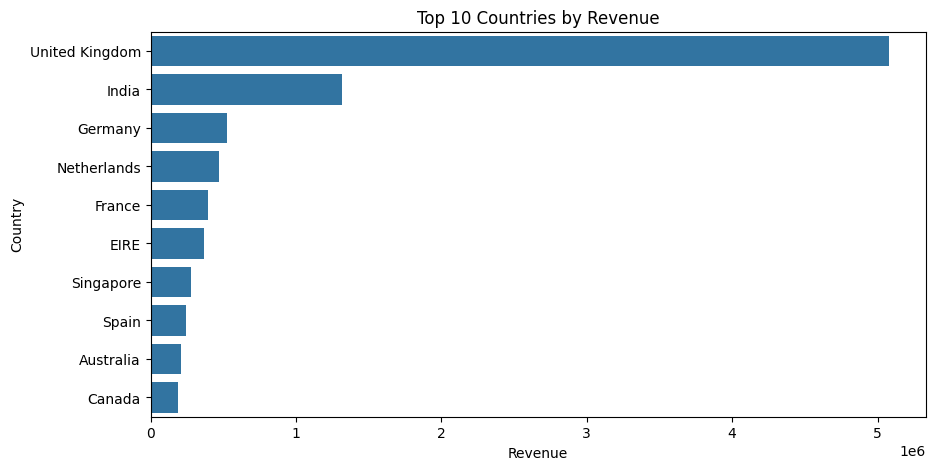

In [23]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

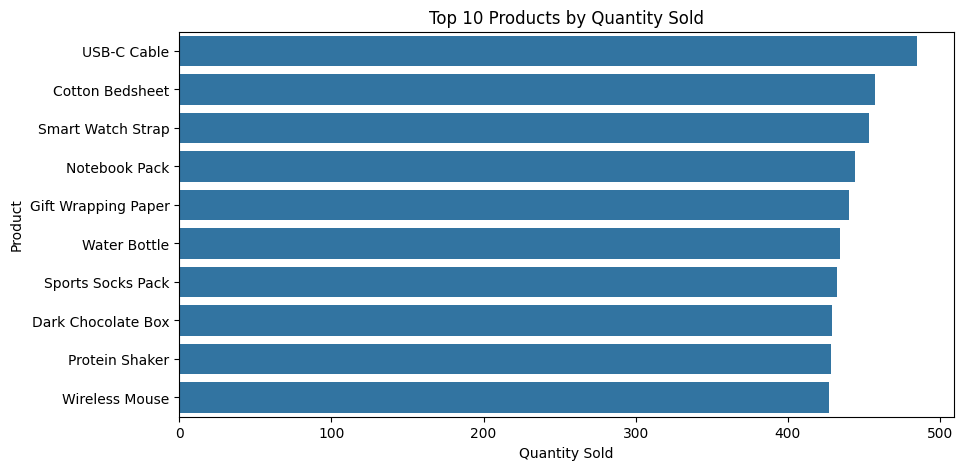

In [24]:
top_products_qty = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products_qty.values, y=top_products_qty.index)
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

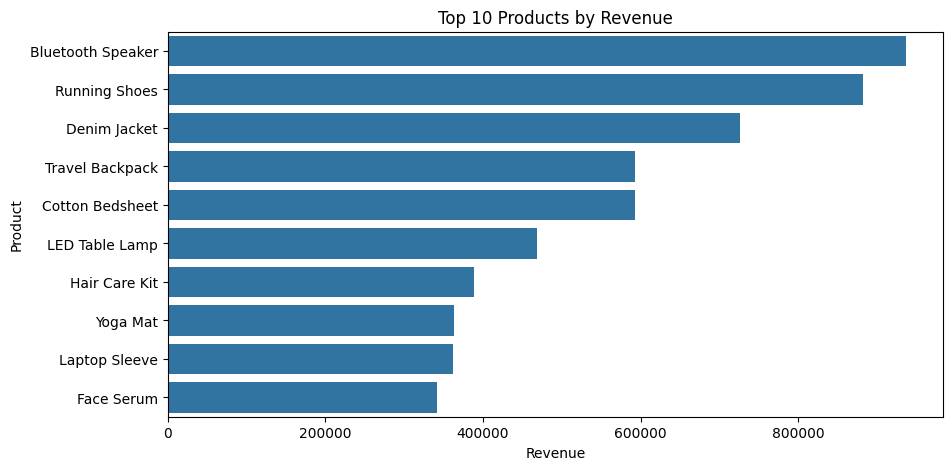

In [25]:
top_products_rev = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products_rev.values, y=top_products_rev.index)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

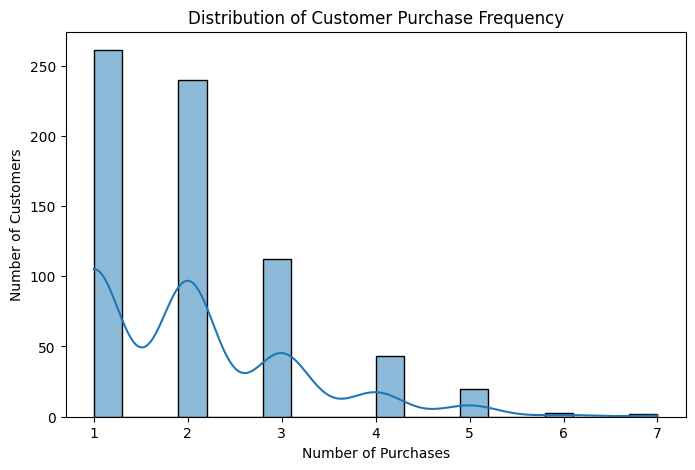

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(customer_df["Frequency"], bins=20, kde=True)
plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

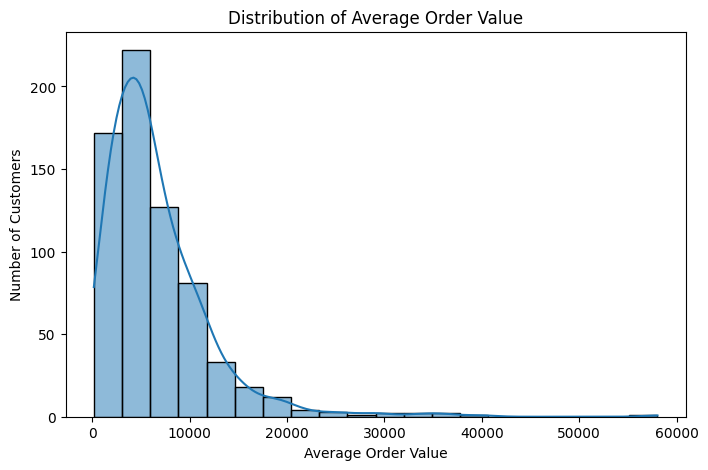

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(customer_df["AvgOrderValue"], bins=20, kde=True)
plt.title("Distribution of Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Number of Customers")
plt.show()

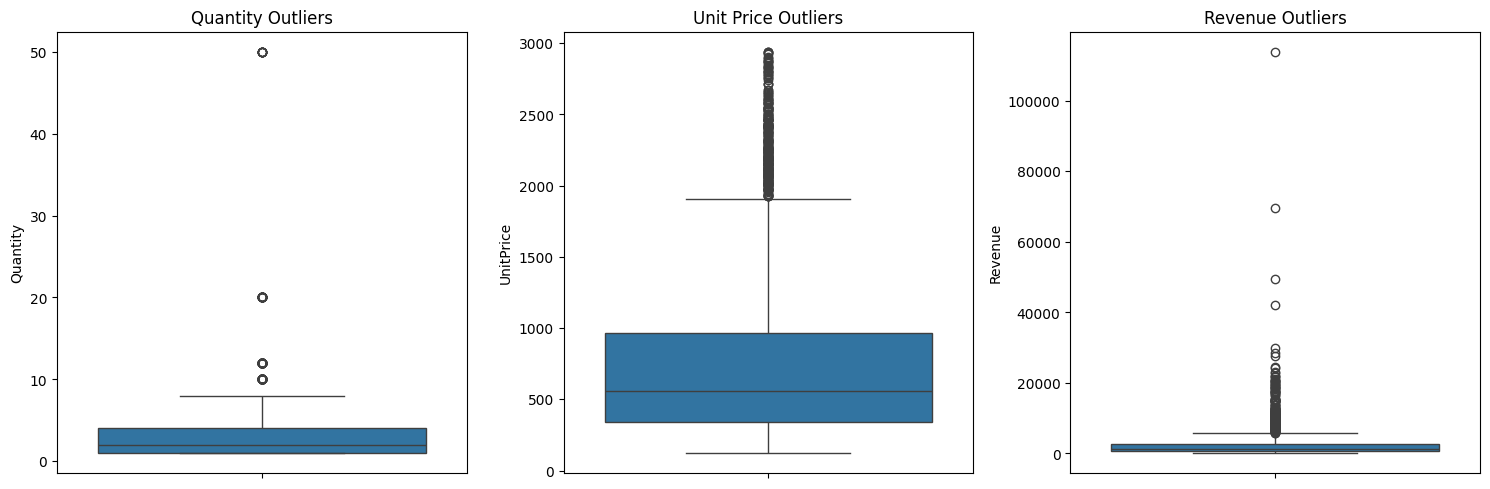

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(y=df["Quantity"], ax=axes[0])
axes[0].set_title("Quantity Outliers")

sns.boxplot(y=df["UnitPrice"], ax=axes[1])
axes[1].set_title("Unit Price Outliers")

sns.boxplot(y=df["Revenue"], ax=axes[2])
axes[2].set_title("Revenue Outliers")

plt.tight_layout()
plt.show()

In [29]:
high_value_customers = customer_df.sort_values("Monetary", ascending=False).head(10)
high_value_customers[["CustomerID", "Monetary", "Frequency", "Recency"]]

,CustomerID,Monetary,Frequency,Recency
551,C10684,116064.96,2,76
201,C10248,79880.85,2,86
127,C10151,75552.30,4,41
400,C10489,73697.71,2,84
317,C10391,59477.06,2,126
578,C10725,58475.82,7,63
310,C10383,55774.29,2,21
123,C10147,55598.45,5,15
397,C10485,53912.82,5,131
588,C10739,53240.09,5,70


In [30]:
rfm_data = customer_df[["Recency", "Frequency", "Monetary"]].copy()

In [31]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

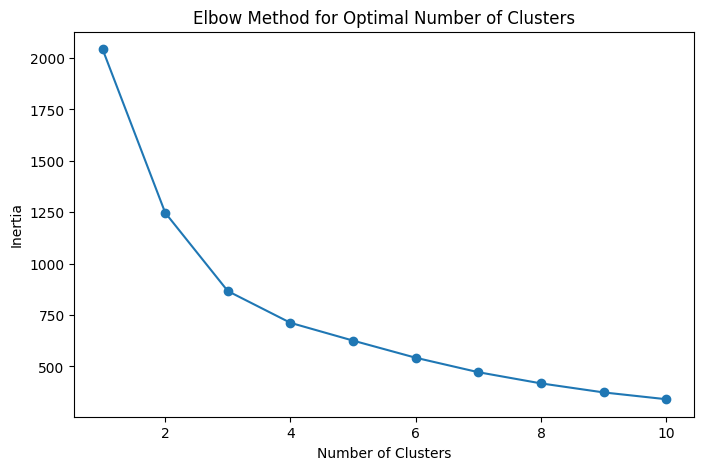

In [32]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [34]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [35]:
cluster_summary = customer_df.groupby("Cluster")[["Recency", "Frequency", "Monetary", "TotalRevenue", "AvgOrderValue"]].mean().round(2)
cluster_summary["CustomerCount"] = customer_df.groupby("Cluster")["CustomerID"].count()
cluster_summary

,Recency,Frequency,Monetary,TotalRevenue,AvgOrderValue,CustomerCount
Cluster,,,,,,
0,66.76,1.81,9370.58,9370.58,5584.18,298
1,75.28,3.53,30601.34,30601.34,9815.12,144
2,225.15,1.40,8100.62,8100.62,5963.34,239


In [38]:
cluster_names = {
    0: "Regular / Occasional Buyer",
    1: "High Value Loyal",
    2: "Inactive / At-Risk"
}

customer_df["ClusterName"] = customer_df["Cluster"].map(cluster_names)
customer_df[["CustomerID", "Cluster", "ClusterName"]].head()

,CustomerID,Cluster,ClusterName
0,C10001,1,High Value Loyal
1,C10003,0,Regular / Occasional Buyer
2,C10004,0,Regular / Occasional Buyer
3,C10005,2,Inactive / At-Risk
4,C10006,1,High Value Loyal


In [37]:
df.shape

(3848, 10)

In [39]:
cluster_summary = customer_df.groupby("Cluster")[["Recency", "Frequency", "Monetary", "TotalRevenue", "AvgOrderValue"]].mean().round(2)
cluster_summary["CustomerCount"] = customer_df.groupby("Cluster")["CustomerID"].count()
print(cluster_summary)

         Recency  Frequency  Monetary  TotalRevenue  AvgOrderValue  \
Cluster                                                              
0          66.76       1.81   9370.58       9370.58        5584.18   
1          75.28       3.53  30601.34      30601.34        9815.12   
2         225.15       1.40   8100.62       8100.62        5963.34   

         CustomerCount  
Cluster                 
0                  298  
1                  144  
2                  239  


In [40]:
customer_df["ClusterName"] = customer_df["Cluster"].map({
    0: "Regular / Occasional Buyer",
    1: "High Value Loyal",
    2: "Inactive / At-Risk"
})

In [42]:
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("dataset", exist_ok=True)

In [43]:
df.to_csv("dataset/cleaned_ecommerce.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [44]:
customer_df.to_csv("dataset/customer_segmentation.csv", index=False)

print("Customer segmentation dataset saved successfully")

Customer segmentation dataset saved successfully


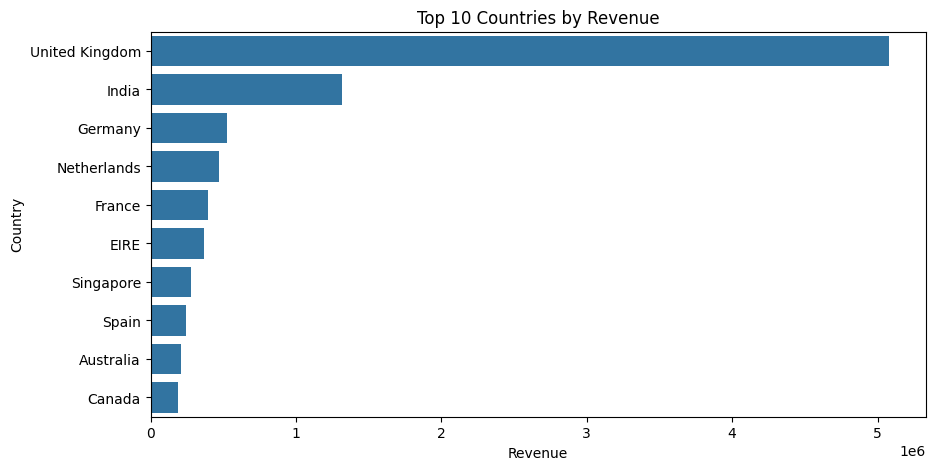

In [45]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=country_sales.values, y=country_sales.index)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.savefig("outputs/top_countries.png", bbox_inches="tight")

plt.show()

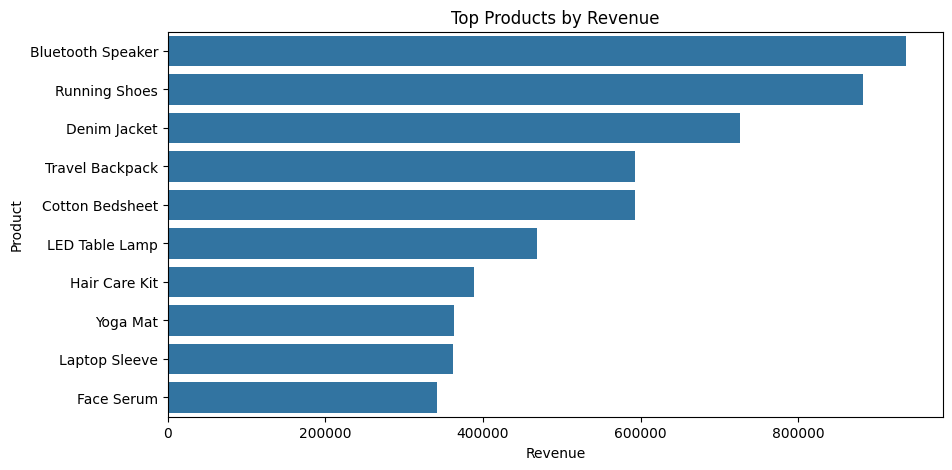

In [46]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.savefig("outputs/top_products.png", bbox_inches="tight")

plt.show()

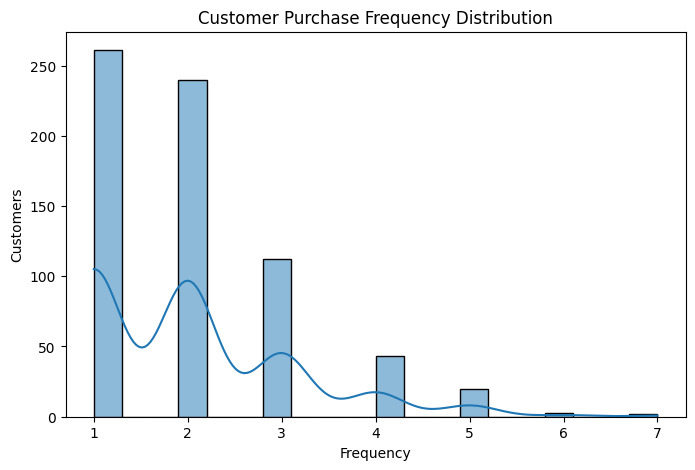

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(customer_df["Frequency"], bins=20, kde=True)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Customers")

plt.savefig("outputs/frequency_distribution.png", bbox_inches="tight")

plt.show()

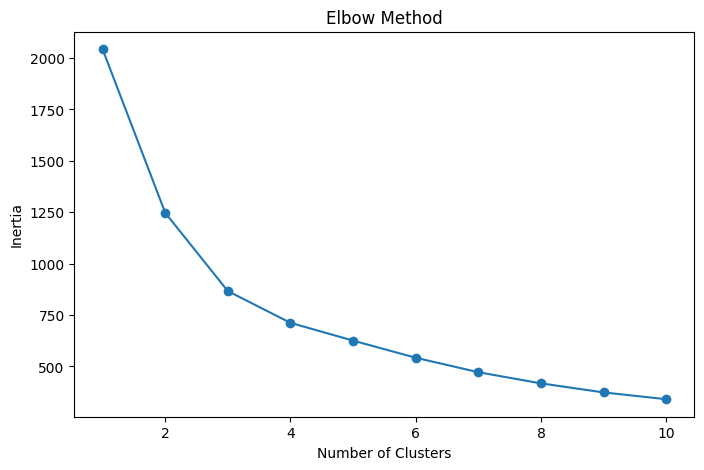

In [48]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.savefig("outputs/elbow_method.png", bbox_inches="tight")

plt.show()

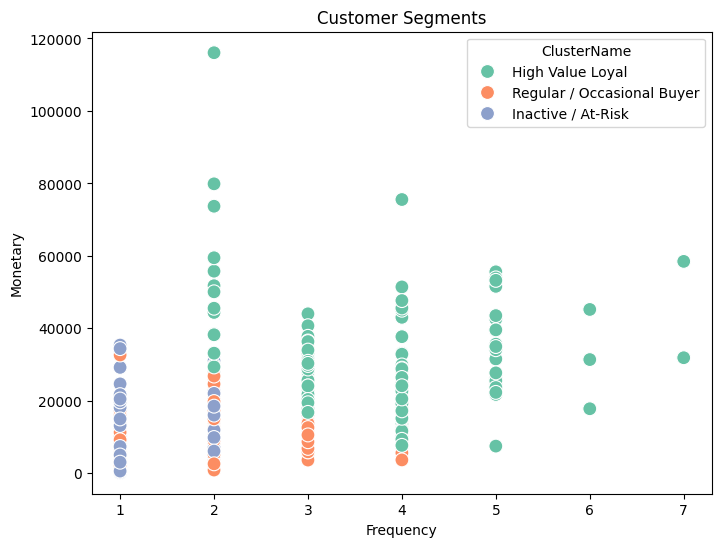

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x="Frequency",
    y="Monetary",
    hue="ClusterName",
    palette="Set2",
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.savefig("outputs/cluster_visualization.png", bbox_inches="tight")

plt.show()

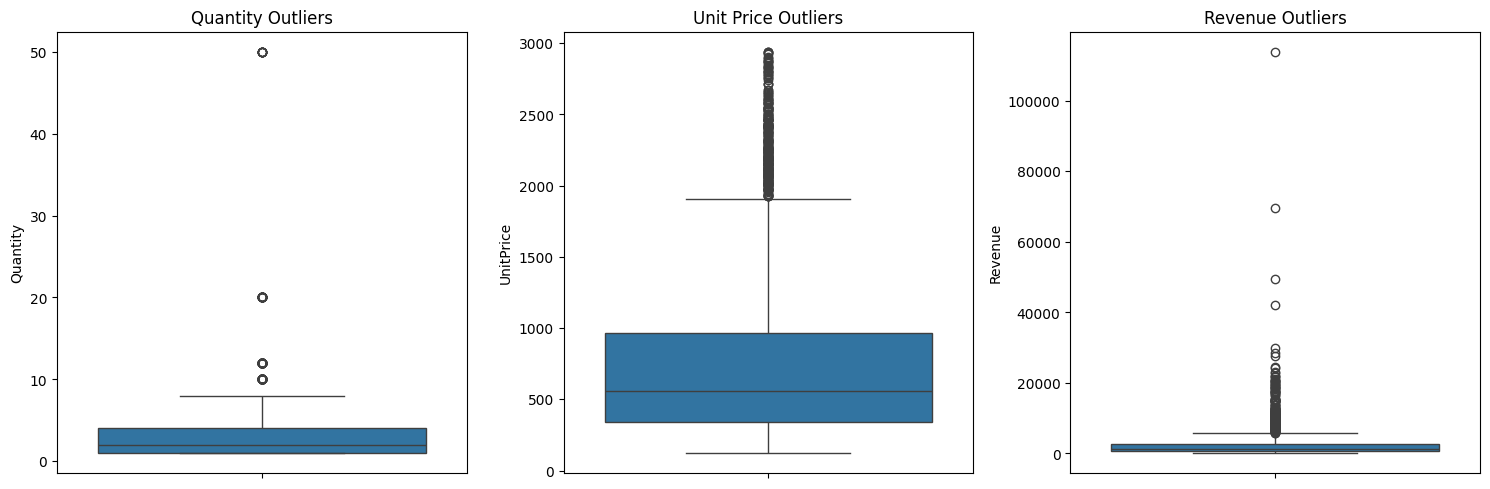

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(y=df["Quantity"], ax=axes[0])
axes[0].set_title("Quantity Outliers")

sns.boxplot(y=df["UnitPrice"], ax=axes[1])
axes[1].set_title("Unit Price Outliers")

sns.boxplot(y=df["Revenue"], ax=axes[2])
axes[2].set_title("Revenue Outliers")

plt.tight_layout()

plt.savefig("outputs/outliers.png", bbox_inches="tight")

plt.show()

In [51]:
from google.colab import files

files.download("dataset/cleaned_ecommerce.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
files.download("dataset/customer_segmentation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
files.download("outputs/top_countries.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
from google.colab import files

files.download("Part1_Ecommerce_Customer_Segmentation.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>